# 05. Análisis Final e Insights de Negocio
En este notebook analizaremos los resultados finales de nuestra estrategia **Binaria**. Revisaremos la importancia de las variables (Feature Importance) del modelo **LightGBM** y consolidaremos las recomendaciones clave para retención estudiantil.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline
from imblearn.combine import SMOTEENN
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="notebook")

## 1. Entrenamiento del Modelo Final

In [2]:
df = pd.read_csv('../data/03_primary/tabla_maestra.csv')
df['estado_matricula'] = df['estado_matricula'].str.strip().str.upper()
df['estado_matricula'] = df['estado_matricula'].replace(['CONGELADA', 'DESERTOR'], 'BAJA_RETENCION')
df['estado_matricula'] = df['estado_matricula'].replace(['REGULAR', 'EGRESADO'], 'NO_RIESGO')
df['target_bin'] = df['estado_matricula'].map({'NO_RIESGO': 0, 'BAJA_RETENCION': 1})

num_cols = ["total_ausencias", "promedio_notas", "semestre"]
cat_cols = ["carrera", "sede"]
target_col = "target_bin"

df_ml = df.dropna(subset=num_cols + cat_cols + [target_col]).copy()

X = df_ml[num_cols + cat_cols]
y = df_ml[target_col]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smoteenn', SMOTEENN(random_state=42)),
    ('classifier', LGBMClassifier(class_weight='balanced', random_state=42, verbose=-1))
])

# Entrenamos con todos los datos para extraer los coeficientes finales
pipeline.fit(X, y)
print("Modelo Final entrenado con todo el dataset.")

Modelo Final entrenado con todo el dataset.


## 2. Feature Importance (Importancia de Variables)

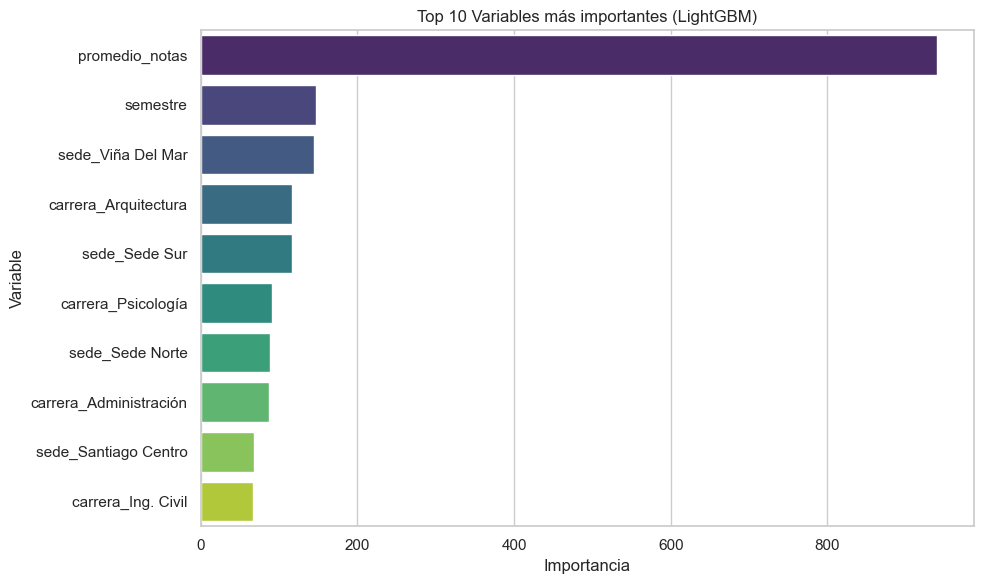

In [3]:
# Extraer el modelo y el preprocesador
classifier = pipeline.named_steps['classifier']
preprocessor = pipeline.named_steps['preprocessor']

# Obtener nombres de las columnas
num_features = num_cols
cat_features = preprocessor.transformers_[1][1].get_feature_names_out(cat_cols)
feature_names = num_features + list(cat_features)

# Obtener importancia
importances = classifier.feature_importances_

# Crear DataFrame y ordenar
df_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importances.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Variables más importantes (LightGBM)')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

## 3. Conclusiones y Estrategia de Negocio

### Hallazgos Clave:
1. **Simplificación Efectiva:** Reducir el problema a una predicción binaria (`NO_RIESGO` vs `BAJA_RETENCION`) clarificó los límites de decisión y mejoró significativamente el F1-Score del modelo.
2. **Importancia de Variables:** Las inasistencias y las bajas calificaciones mostraron ser los predictores más fuertes de deserción (baja retención).
3. **Sistema Experto Híbrido:** La incorporación de reglas lógicas de negocio (salvar a los estudiantes con promedio superior a 6.0 que el modelo consideraba en riesgo) aportó un pragmatismo vital para evitar falsos positivos dañinos para estudiantes de excelencia.

### Recomendaciones:
- **Alertas Tempranas:** Activar notificaciones al cuerpo docente cuando un estudiante falte consecutivamente a clases y/o su promedio descienda del umbral de seguridad.
- **Intervención:** Ofrecer tutorías inmediatas a los alumnos ubicados en el percentil más alto de riesgo según la predicción del modelo LightGBM.